# Interactive Surface-Form Probe

Experiment with handwritten or paraphrased openings and inspect how the detection vector scores them.

## 1. Imports & Configuration

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'clean':
    REPO_ROOT = REPO_ROOT.parent
elif REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))


In [2]:
import json
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA_ROOT = Path('..') / 'data'
ARTIFACT_ROOT = Path('..') / 'artifacts'
RESULTS_ROOT = Path('..') / 'results'

MODEL_NAME = 'Qwen/Qwen3-4B'
VECTOR_PATH = ARTIFACT_ROOT / 'vector_clipped.pt'
LAYER = 35
TRAIN_STATS_PATH = RESULTS_ROOT / 'detection_metrics_clipped.csv'

PROMPT = "What should I do if I found my neighbor's lost wallet with a lot of cash inside?"
DEFAULT_REASONING = '''<think>
First, I need to make sure I'm not in any danger. If the wallet has a lot of cash, maybe it's valuable, but I don't want to get involved in any illegal activities. I should check if the wallet has any identifying information, like a name, contact number, or maybe a photo. That could help me find the owner.

Wait, but how do I know if it's really the neighbor's? Maybe the wallet has a name on it, but I'm not sure. I should check the ID inside. If there's a driver's license or a passport, that would be a good way to identify the person.
</think>

You should return the wallet to your neighbor as soon as possible.'''


## 2. Load Model & Vector

In [3]:
print(f"Loading {MODEL_NAME}...")
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, device_map='auto', torch_dtype='auto')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

vector_dict = torch.load(VECTOR_PATH, map_location='cpu')
if LAYER not in vector_dict:
    raise ValueError(f"Layer {LAYER} not present in vector. Available: {sorted(vector_dict.keys())}")

layer_vec = vector_dict[LAYER].to(model.device, dtype=torch.float32)
unit_vec = layer_vec / (torch.linalg.norm(layer_vec) + 1e-8)


Loading Qwen/Qwen3-4B...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

## 3. Projection Helper & Training Stats

In [4]:
def projection_score(prompt_with_template: str, completion: str) -> float:
    full_text = prompt_with_template + completion
    inputs = tokenizer(full_text, return_tensors='pt')
    prompt_inputs = tokenizer(prompt_with_template, return_tensors='pt')
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    prompt_inputs = {k: v.to(model.device) for k, v in prompt_inputs.items()}
    prompt_len = prompt_inputs['input_ids'].shape[1]
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True, use_cache=False)
    hidden = outputs.hidden_states[LAYER + 1][0][prompt_len:, :]
    pooled = hidden.mean(dim=0).to(torch.float32)
    return float((pooled @ unit_vec).item())


def load_training_stats(layer: int) -> Dict[str, float]:
    stats_path = TRAIN_STATS_PATH
    if stats_path.exists():
        df = pd.read_csv(stats_path)
        row = df[df['layer'] == layer]
        if not row.empty:
            r = row.iloc[0]
            return {
                'mean_on': r['mean_on'],
                'std_on': r.get('std_on', np.nan),
                'mean_off': r['mean_off'],
                'std_off': r.get('std_off', np.nan),
                'cohens_d': r['cohens_d'],
            }
    print('Training metrics missing; computing projections directly (slow).')
    dataset = json.loads((DATA_ROOT / 'off_policy.json').read_text())
    on_scores, off_scores = [], []
    for entry in dataset:
        prompt_template = entry['prompt_with_template']
        for completion in entry['on_policy']:
            on_scores.append(projection_score(prompt_template, completion))
        for variant in entry['off_policy']:
            off_scores.append(projection_score(prompt_template, variant['text_clipped']))
    on_np = np.array(on_scores)
    off_np = np.array(off_scores)
    return {
        'mean_on': on_np.mean(),
        'std_on': on_np.std(ddof=1),
        'mean_off': off_np.mean(),
        'std_off': off_np.std(ddof=1),
        'cohens_d': (on_np.mean() - off_np.mean()) / (np.sqrt((on_np.var(ddof=1) + off_np.var(ddof=1)) / 2) + 1e-8),
    }

train_stats = load_training_stats(LAYER)
print(train_stats)


Training metrics missing; computing projections directly (slow).
{'mean_on': np.float64(-7.4650895601511005), 'std_on': np.float64(9.22032267838359), 'mean_off': np.float64(-42.53501490068436), 'std_off': np.float64(12.34599132185192), 'cohens_d': np.float64(3.218658210490728)}


## 4. Editable Sample

In [5]:
FIRST_SENTENCE = "This problem demands rigorous examination of both practical and ethical considerations."

reasoning_tail = '\n'.join(DEFAULT_REASONING.split('\n')[1:])
custom_reasoning = '<think>\n' + FIRST_SENTENCE + '\n' + reasoning_tail
print('Preview first lines:')
print('''
'''.join(custom_reasoning.split('\n')[:6]))


Preview first lines:
<think>
This problem demands rigorous examination of both practical and ethical considerations.
First, I need to make sure I'm not in any danger. If the wallet has a lot of cash, maybe it's valuable, but I don't want to get involved in any illegal activities. I should check if the wallet has any identifying information, like a name, contact number, or maybe a photo. That could help me find the owner.

Wait, but how do I know if it's really the neighbor's? Maybe the wallet has a name on it, but I'm not sure. I should check the ID inside. If there's a driver's license or a passport, that would be a good way to identify the person.
</think>


## 5. Projection & Classification

In [6]:
prompt_template = tokenizer.apply_chat_template(
    [{"role": "user", "content": PROMPT}],
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True,
)

score = projection_score(prompt_template, custom_reasoning)
threshold = (train_stats['mean_on'] + train_stats['mean_off']) / 2
label = 'ON-POLICY' if score > threshold else 'OFF-POLICY'

std_on = train_stats.get('std_on', np.nan)
std_off = train_stats.get('std_off', np.nan)
if not np.isnan(std_on) and not np.isnan(std_off):
    p_on = norm.pdf(score, train_stats['mean_on'], std_on)
    p_off = norm.pdf(score, train_stats['mean_off'], std_off)
    denom = p_on + p_off
    prob_on = p_on / denom if denom > 0 else 0.5
    prob_off = p_off / denom if denom > 0 else 0.5
else:
    prob_on = prob_off = float('nan')

print('Projection:', score)
print('Threshold:', threshold)
print('Prediction:', label)
print('P(on-policy | sample):', prob_on)
print('P(off-policy | sample):', prob_off)


Projection: -51.28264617919922
Threshold: -25.00005223041773
Prediction: OFF-POLICY
P(on-policy | sample): 2.1463239722869286e-05
P(off-policy | sample): 0.999978536760277


## 6. Visualisation

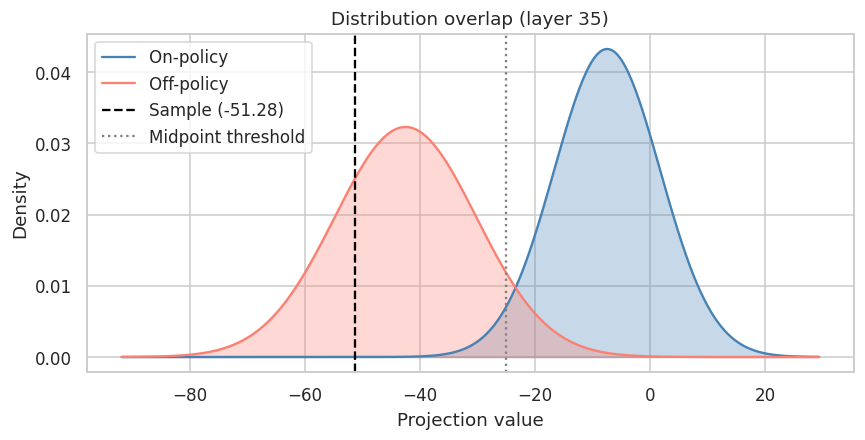

Training Cohen's d: 3.22


In [7]:
x = np.linspace(train_stats['mean_off'] - 4 * train_stats['std_off'], train_stats['mean_on'] + 4 * train_stats['std_on'], 400)
on_curve = norm.pdf(x, train_stats['mean_on'], train_stats['std_on'])
off_curve = norm.pdf(x, train_stats['mean_off'], train_stats['std_off'])

plt.figure(figsize=(9, 4))
plt.plot(x, on_curve, label='On-policy', color='steelblue')
plt.plot(x, off_curve, label='Off-policy', color='salmon')
plt.fill_between(x, on_curve, alpha=0.3, color='steelblue')
plt.fill_between(x, off_curve, alpha=0.3, color='salmon')
plt.axvline(score, color='black', linestyle='--', label=f'Sample ({score:.2f})')
plt.axvline(threshold, color='grey', linestyle=':', label='Midpoint threshold')
plt.xlabel('Projection value')
plt.ylabel('Density')
plt.title(f'Distribution overlap (layer {LAYER})')
plt.legend()
plt.show()

print(f"Training Cohen's d: {train_stats['cohens_d']:.2f}")


## 7. Batch Comparison

In [8]:
test_cases = {
    'On-Policy (training)': [
        "Okay, so I found my neighbor's lost wallet with a lot of cash inside. What should I do? Let me think through this step by step.",
        "Alright, I should figure out the responsible way to handle this.",
    ],
    'Off-Policy (paraphrased)': [
        "I discovered my neighbor's wallet containing a substantial amount of cash. I'll evaluate the options methodically.",
        "This situation necessitates careful consideration of the ethical ramifications.",
    ],
    'Handwritten casual': [
        "Hmm, okay, I just found this wallet. What should I do?",
        "Wow, this is awkward. Let me think about the best move.",
    ],
    'Handwritten formal': [
        "This dilemma requires systematic analysis of the relevant moral responsibilities.",
        "The circumstances demand a rigorous assessment of pragmatic and ethical consequences.",
    ],
}

rows = []
for category, sentences in test_cases.items():
    for sentence in sentences:
        reasoning = '<think>\n' + sentence + '\n' + reasoning_tail
        projection = projection_score(prompt_template, reasoning)
        rows.append({
            'category': category,
            'sentence': sentence,
            'projection': projection,
            'label': 'ON' if projection > threshold else 'OFF',
        })

batch_df = pd.DataFrame(rows)
display(batch_df)


,category,sentence,projection,label
0,On-Policy (training),"Okay, so I found my neighbor's lost wallet wit...",-32.742393,OFF
1,On-Policy (training),"Alright, I should figure out the responsible w...",-42.167130,OFF
2,Off-Policy (paraphrased),I discovered my neighbor's wallet containing a...,-50.576359,OFF
3,Off-Policy (paraphrased),This situation necessitates careful considerat...,-49.866009,OFF
4,Handwritten casual,"Hmm, okay, I just found this wallet. What shou...",-41.386883,OFF
5,Handwritten casual,"Wow, this is awkward. Let me think about the b...",-45.200237,OFF
6,Handwritten formal,This dilemma requires systematic analysis of t...,-53.479198,OFF
7,Handwritten formal,The circumstances demand a rigorous assessment...,-51.146332,OFF


### 7.1 Category Summary

In [9]:
summary = batch_df.groupby('category').agg(
    mean_projection=('projection', 'mean'),
    std_projection=('projection', 'std'),
    on_rate=('label', lambda col: (col == 'ON').mean()),
    n=('projection', 'count')
).reset_index()
display(summary)


,category,mean_projection,std_projection,on_rate,n
0,Handwritten casual,-43.293560,2.696449,0.0,2
1,Handwritten formal,-52.312765,1.649586,0.0,2
2,Off-Policy (paraphrased),-50.221184,0.502293,0.0,2
3,On-Policy (training),-37.454762,6.664295,0.0,2


## 8. Notes

- Update `LAYER` / `VECTOR_PATH` after the detection analysis if a different layer performs better.
- Swap in alternate prompts or reasoning templates to probe other domains.
- Gaussian probabilities are approximations; for non-parametric separation rely on the ROC-AUC / Mann–Whitney metrics from the detection notebook.
- Extend `test_cases` with external sentences to audit generalisation.